In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import FastICA
from utils import load_images
import joblib
import pathlib
from pathlib import Path

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load all 9 ICA models and images

In [2]:
basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")

model_list = []
for entry in basepath.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        model_list.append(model)

print(model_list)

images = load_images(crop_size=36)
print("loaded images shape", images.shape)

n_components = model.components_.shape[0]

[FastICA(n_components=40, random_state=752767290, whiten='unit-variance'), FastICA(n_components=40, random_state=3653403230, whiten='unit-variance'), FastICA(n_components=40, random_state=70985653, whiten='unit-variance'), FastICA(n_components=40, random_state=323153948, whiten='unit-variance'), FastICA(n_components=40, random_state=1322117303, whiten='unit-variance'), FastICA(n_components=40, random_state=2195314464, whiten='unit-variance'), FastICA(n_components=40, random_state=2735729614, whiten='unit-variance'), FastICA(n_components=40, random_state=175979944, whiten='unit-variance'), FastICA(n_components=40, random_state=1158725111, whiten='unit-variance')]
loaded images shape (20000, 36, 36)


### One-hot encode the 9x40-dim ICA activations and visualize the generated images

In [3]:
all_images = []
for hot_idx in range(n_components):
    one_hot_activation = np.zeros(n_components)
    one_hot_activation[hot_idx] = 100
    one_hot_activation = one_hot_activation.reshape(1, -1)
    image = []
    for model in model_list:
        image_patch = model.inverse_transform(one_hot_activation)
        image_patch = image_patch.reshape(12, 12)
        image.append(image_patch)
    image = np.array(image)
    all_images.append(image) 

In [4]:
all_images = np.array(all_images)

In [5]:
all_images.shape

(40, 9, 12, 12)

In [6]:
all_images = all_images.transpose(1, 0, 2, 3)
all_images.shape

(9, 40, 12, 12)

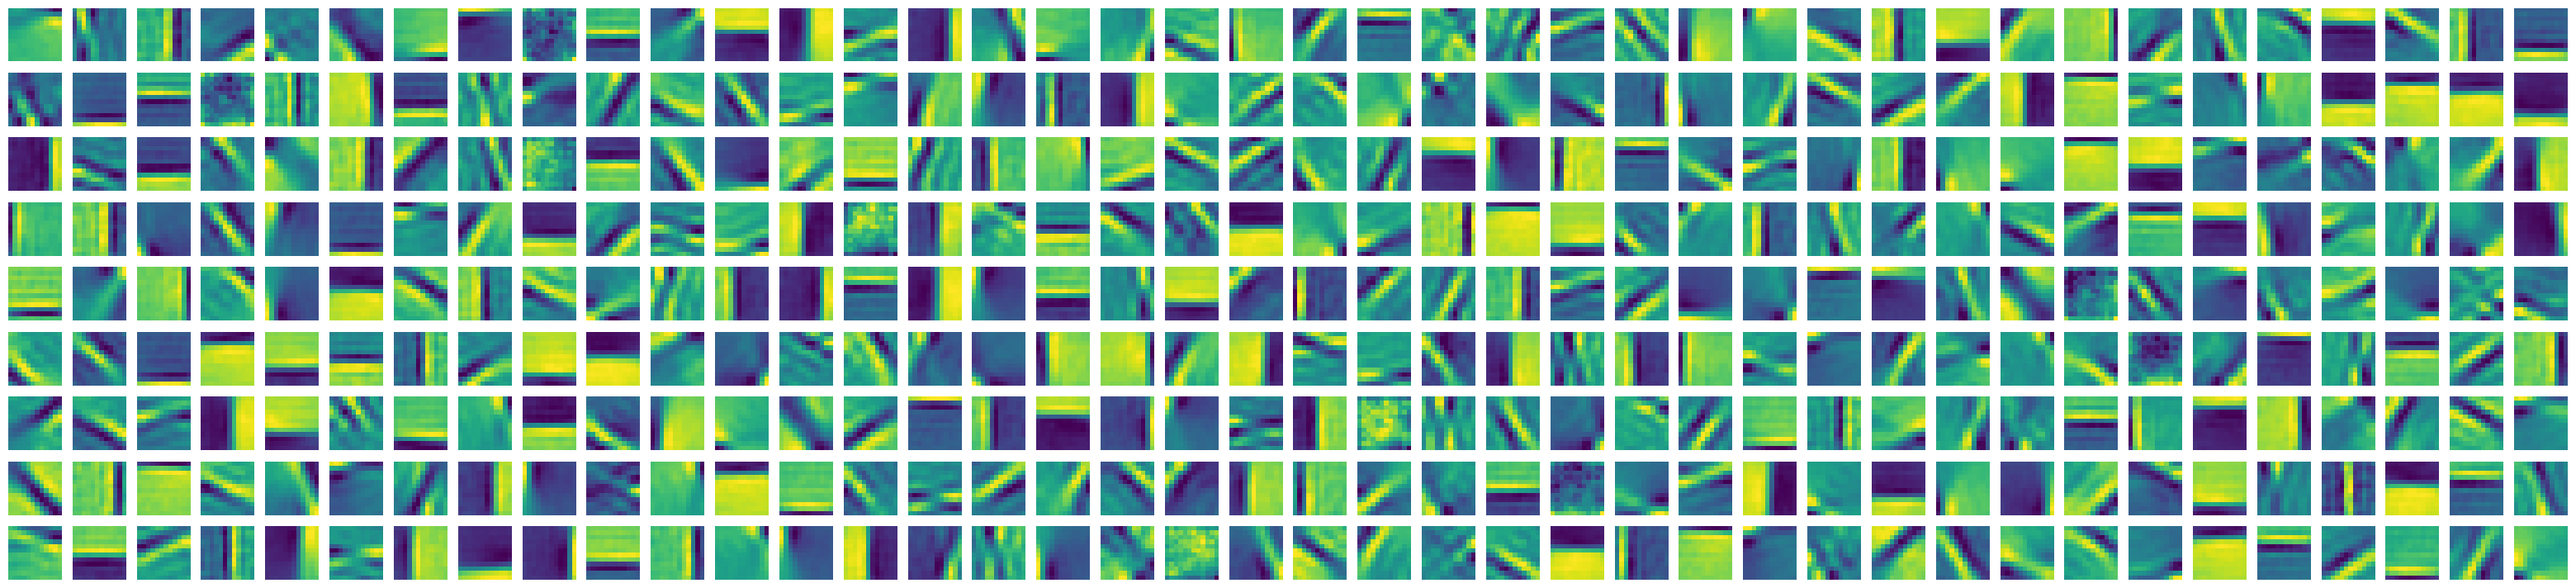

In [7]:
fig, axs = plt.subplots(9, 40, figsize=(40, 9))
for i in range(9):
    for j in range(40):
        axs[i, j].imshow(all_images[i, j])
        axs[i, j].axis("off")

In [8]:
all_images = all_images.transpose(1, 0, 2, 3)
all_images.shape

(40, 9, 12, 12)

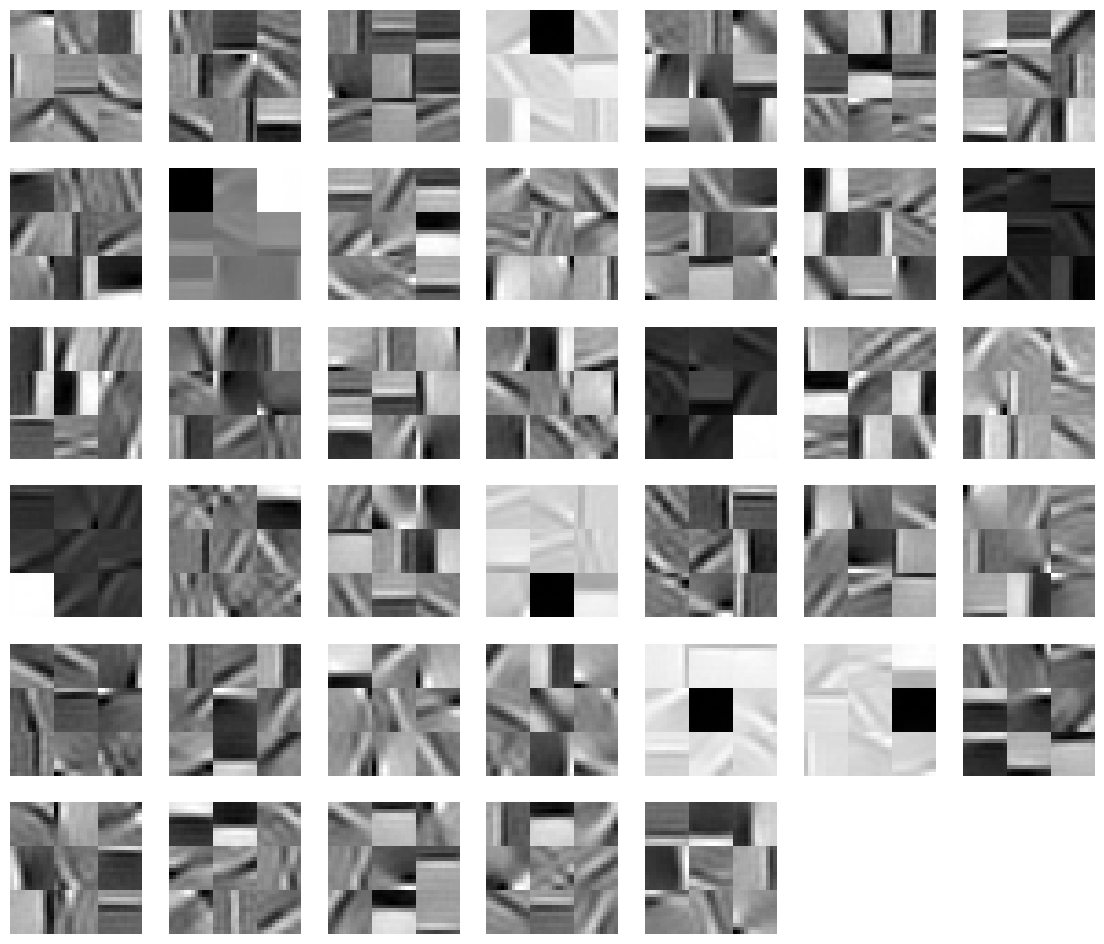

In [18]:
fig, axs = plt.subplots(6, 7, figsize=(2*7, 2*6))
for idx, ax in enumerate(axs.flatten()):
    if idx < 40:
        image = all_images[idx]
        single_image = np.vstack([np.hstack(image[:3]), np.hstack(image[3:6]), np.hstack(image[6:9])])
        ax.imshow(single_image, cmap="gray")
    ax.axis("off")